## Exercise 13.1 (sum of two integers)
Write a program that as input takes a single line with two integers and outputs their sum. A valid input line consist of two integers separated by one or more white spaces. Input can be preceded and followed by white spaces. The program should repeat asking for input until a valid input is given.
```
Input two integers, separated by space: 2 a
invalid input
Input two integers, separated by space: 2 3.0
invalid input
Input two integers, separated by space: 2 3
Sum = 5
```
Hint. Use exceptions to handle illegal input.

In [2]:
while True: 
    try: 
        x, y = (input("Input two integers, separated by space: ").split())
        x, y = int(x), int(y)
        print("Sum =", x + y)
    except ValueError: 
        print("Invalid input")
    else: 
        break


Invalid input
Sum = 6


## Exercise 13.2 (transposing)
In this exercise we assume that a file stores a matrix, where the rows are stored in consecutive lines in the file, and where column values are separated by ;. Your task is to make a program that writes the transposed matrix to another file - see example below.

Input:
```
1;2;3;4
5;6;7;8
9;10;11;12
Output:

1;5;9
2;6;10
3;7;11
4;8;12
```
The program should ask the user for the name of an input file and the name of an output file, read the matrix in the input file, and write the transposed matrix to the output file.

Your solution should handle the following potential errors.

If input file does not exist, report this to the user and start over.

If output file already exists, warn the user, and ask the user to confirm to overwrite the existing file.

If the lines in the input file have a different number of values, i.e. the input is not a valid matrix, report this to the user, and start over without writing any output.

Hint. Use the string method split to split a line into a list of values.

In [ ]:
while True:
    try: 
        # read
        file_in = input("Input File: ")
        with open("4. Semester\IPSA\\txt\\" + file_in) as f: 
            mat = [ 
                [int(item.strip()) for item in line.split(";")] # Make Rows
                for line in open("4. Semester\IPSA\in_txt.txt") # Make Coloums
            ]
            matT = list(zip(*mat))
        
        # write
        file_out = input("Output File: ")
        with open("4. Semester\IPSA\\txt\\" + file_out, "x") as f: 
            for row in matT:
                f.write(";".join(map(str, row)) + "\n")

    except FileNotFoundError:
        print("File Not Found")

    except ValueError:
        print("Invalid matrix")

    except KeyboardInterrupt:
        print("Done")
        break

    except FileExistsError:
        print("File Exists \n Do you want to overwrite? \n")
        a = input("(y/n): ")
        if a == "y": 
            with open("4. Semester\IPSA\\txt\\" + file_out, "w") as f: 
                for row in matT:
                    f.write(";".join(map(str, row)) + "\n")
        else:
            print("Nothing happens")
            
        

## Exercise 13.3 (grade statistics)
In this exercise you should write a program that reads two files: one respectively containing the names and address of students, and one containing exam results. The output of the program should be a summary of the exam performances.

The student list is stored in a file, with one student per line, consisting of the three fields, separated by ; : the unique student id, name and address.

```
107;Donald Duck;Duck Steet 13, Duckburg
243;Mickey Mouse;Mouse Street 42, Duckburg
465;Goofy;Clumsy Road 7, Duckburg
777;Scrooge McDuck;Money Street 1, Duckburg
```

The second file contains the list of exam results, consisting of a line per grade given, consisting of a triple, with values separated by ; : student id, course name, and grade.

```
107;Programming;10
107;Mathematics;8
107;Computability;7
243;Programming;10
243;Computer forensic;10
243;Computability;9
465;Mathematics;6
```

The program should print a summary like the below:

```
Student id Name            Average #Courses
===========================================
107        Donald Duck        8.33        3
243        Mickey Mouse       9.67        3
465        Goofy              6.00        1
777        Scrooge McDuck     0.00        0
```

In [2]:
from tabulate import tabulate

try: 
    # Get students and make a list of dicts
    with open("4. Semester\IPSA\\txt\student.txt") as f: 
        students_list = [
                [item.strip() for item in line.split(";")] # Make Rows
                for line in f # Make Columns
            ]
        student_dict = [dict(zip(["id", "name", "address"], s)) for s in students_list]
        for student in student_dict:
            student["grades"] = []
        print(student_dict)
    
    # Add grades to the dicts 
    with open("4. Semester\IPSA\\txt\\results.txt") as f: 
        results_list = [
                [item.strip() for item in line.split(";")] # Make Rows
                for line in f # Make Columns
            ]
        for student in student_dict:
            for grade in results_list:
                if student["id"] == grade[0]:
                    student["grades"].append((grade[1], grade[2]))
        print("\n ---- \n", student_dict, "\n ------ \n")

    with open("4. Semester\IPSA\\txt\\sum.txt", "w") as f:
        # Column headers
        headers = ["Student id", "Name", "Average", "#Courses"]
        
        # Create formatted table data
        table_data = []
        for student in student_dict:
            id = student["id"]
            name = student["name"]
            courses = len(student["grades"])
            if courses == 0: 
                avg = 0.0
            else: 
                avg = round(sum([int(x[1]) for x in student["grades"]])/courses,2)
            table_data.append([id, name, avg, courses])
        
        # Create formatted table
        table = tabulate(table_data, headers=headers, tablefmt="grid")  # Change "grid" to "plain" or "pipe" for different styles

        f.write(table)    

except FileNotFoundError:
    print("File not found")

File not found


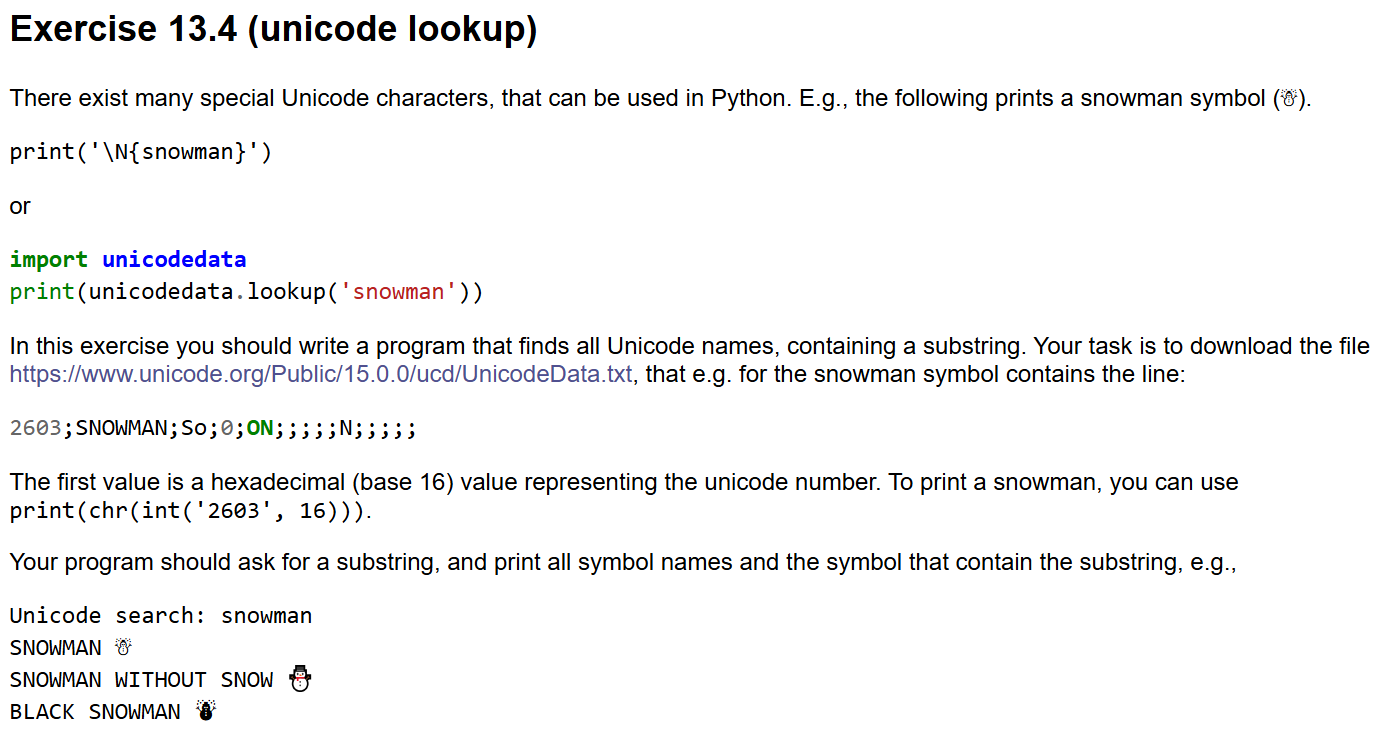

In [ ]:
# Step 1: Open and Read the Local UnicodeData.txt File
with open("4. Semester\\IPSA\\txt\\UnicodeData.txt", "r", encoding="utf-8") as file:
    unicode_data = file.readlines()  # Read all lines

# Step 2: Ask User for Search Term
search_term = input("Enter a substring to search for in Unicode names: ").upper()

# Step 3: Process Data and Find Matches
matches = []
for line in unicode_data:
    fields = line.split(";")
    if len(fields) > 1:
        unicode_hex = fields[0]  # Unicode hex value
        name = fields[1]  # Unicode character name
        
        if search_term in name:  # Check if substring is in the name
            unicode_char = chr(int(unicode_hex, 16))  # Convert hex to character
            matches.append((name, unicode_char))

# Step 4: Print Results
if matches:
    print("\nMatches found:")
    for name, char in matches:
        print(f"{name} {char}")
else:
    print("No matches found.")


## Exercise 14.1 (identical pairs)
Write a method identical_pairs(L) that given a list L returns the number of index pairs (i, j) where i < j and L[i] == L[j]. E.g., identical_pairs([3, 2, 3, 1, 2, 3, 1]) should return 5.

Your code should be able to handle inputs with a million values.

Write tests for your code.

Hint: Apply sorted to the list and only do one scan over the list to compute the result.

In [ ]:
import random

def identical_pairs(L):
    ''' 
    Return number of index pairs (i, j) where i < j and L[i] == L[j]
    Requires list as input 
    Returns integer
    '''
    assert isinstance(L, list), f'{type(L)}'
    
    sort = sorted(L)
    num = 0
    for i in range(len(sort)-1): 
        k = i + 1
        while k <= len(sort)-1 and sort[i] == sort[k]:
            num += 1
            k += 1
    
    assert isinstance(num, int)

    return num

# Using assertions for automatic verification
assert identical_pairs([3, 2, 3, 1, 2, 3, 1]) == 5
assert identical_pairs([1, 1, 1, 1]) == 6
assert identical_pairs([1, 2, 3, 4]) == 0
assert identical_pairs([]) == 1, f'{"variabel"}'
assert identical_pairs([1]) == 0

# Generate a list of 100 random numbers between 1 and 10
random_list = [random.randint(1, 100) for _ in range(100)]
print("Number of identical pairs:", identical_pairs(random_list))

AssertionError: variabel